#   Simple Multilayer Perception

Something simple as a reminder exercise how to use TensorFlow/Keras.
No data cleaning, no data processing, only the model bit to remind myself how to use the Keras API.

In [1]:
from sklearn import datasets
import tensorflow as tf
import keras
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

2024-06-23 16:05:07.531898: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-06-23 16:05:07.574165: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-23 16:05:08.819938: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


I just need any regression dataset.
The california housing dataset will do.
I don't even need to know what the variables are for this exercise
(although obviously some simple data processing would go a super long way to making the model better).

In [2]:
X, y = datasets.fetch_california_housing(return_X_y=True)
y = y.reshape(y.size, 1)
X = tf.convert_to_tensor(X, dtype=tf.float32)
y = tf.convert_to_tensor(y, dtype=tf.float32)

2024-06-23 16:05:10.840902: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-23 16:05:10.957709: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-23 16:05:10.957769: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-23 16:05:10.963292: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-23 16:05:10.963499: I external/local_xla/xla/stream_executor

Split the dataset to 3 parts.
Train + Validation are jointly used while fitting model weights.
Test is for testing out-of-sample model performance post-estimation.

In [3]:
ds = tf.data.Dataset.from_tensor_slices((X, y))
ds_left, ds_test = keras.utils.split_dataset(ds, left_size=0.9, seed=123456)
ds_train, ds_val = keras.utils.split_dataset(ds_left, left_size=0.9, seed=234567)
ds_train = ds_train.shuffle(buffer_size=ds_train.cardinality(), seed=1122334).batch(32)
ds_test = ds_test.shuffle(buffer_size=ds_test.cardinality(), seed=2233445).batch(32)
ds_val = ds_val.shuffle(buffer_size=ds_val.cardinality(), seed=3344556).batch(32)

2024-06-23 16:05:14.442080: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-06-23 16:05:17.333712: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Simple 3-hidden layer model with input normalisation.
Build using the Sequential API.
All the default compile options.

In [4]:
model = keras.Sequential()
model.add(keras.Input(shape=tuple(ds.element_spec[0].shape)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(units=100, activation='relu'))
model.add(keras.layers.Dense(units=100, activation='relu'))
model.add(keras.layers.Dense(units=100, activation='relu'))
model.add(keras.layers.Dense(units=1, activation='linear'))
model.compile(optimizer='adam', loss='mse', metrics=['r2_score',])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,233 (82.94 KB)

 Trainable params: 21,217 (82.88 KB)

 Non-trainable params: 16 (64.00 B)

Simple fit call with early stopping callback.

In [5]:
_earlystop = keras.callbacks.EarlyStopping(monitor='val_r2_score', patience=5, start_from_epoch=0, restore_best_weights=True)
history = model.fit(x=ds_train, validation_data=ds_val, epochs=100, callbacks=[_earlystop,])

Epoch 1/100


I0000 00:00:1719129918.866214    9483 service.cc:145] XLA service 0x7f61a80210d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1719129918.866286    9483 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2024-06-23 16:05:18.894089: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-06-23 16:05:19.037781: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1719129920.092779    9610 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_684', 8 bytes spill stores, 8 bytes spill loads



 85/523 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0580 - r2_score: -0.6499

I0000 00:00:1719129920.945616    9483 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


523/523 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.9503 - r2_score: 0.2533 - val_loss: 0.7522 - val_r2_score: 0.3745
Epoch 2/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4213 - r2_score: 0.6693 - val_loss: 0.7695 - val_r2_score: 0.3550
Epoch 3/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4085 - r2_score: 0.6862 - val_loss: 0.7650 - val_r2_score: 0.3619
Epoch 4/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4009 - r2_score: 0.6883 - val_loss: 1.0141 - val_r2_score: 0.1661
Epoch 5/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3804 - r2_score: 0.6989 - val_loss: 0.8388 - val_r2_score: 0.2954
Epoch 6/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3728 - r2_score: 0.7080 - val_loss: 0.8069 - val_r2_score: 0.3430


Show the training and validation plots.

In [6]:
import matplotlib.pyplot as plt

Nothing complex, and certainly not TensorBoard.
I will mess with TensorBoard again some other time.

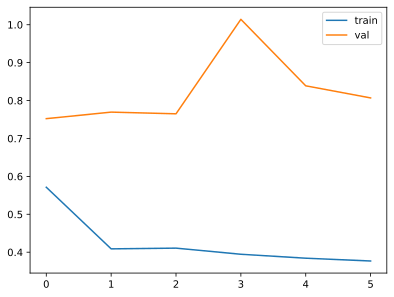

In [7]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

The $R^{2}$ score looks even worse.
Not a concern for now since this is not an actual model for anything, just a practice exercise.
But this is anyway still worrying.

Chances are: (1) whole bunch of categorical variables were not dummy encoded, so their weights make exactly zero sense; (2) some variables could have used log or quadratic transformation for better interpretability and fit; (3) more contextual variables are required such as year, month, locality, density of nearby amenities, home age, preexisting decorations and faults; (4) this model structure makes no sense for this problem.

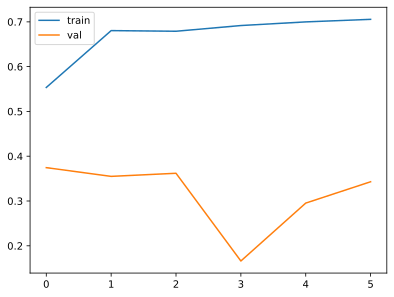

In [8]:
plt.plot(history.history['r2_score'], label='train')
plt.plot(history.history['val_r2_score'], label='val')
plt.legend()
plt.show()

Evaluate on test to check test performance.

In [9]:
result = model.evaluate(ds_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.2566 - r2_score: -0.5023


Print result more legibly.

In [10]:
print(f'{"MSE Loss":>12}: {result[0]:.3f}')
print(f'{"R2 Score":>12}: {result[1]:.3f}')

    MSE Loss: 0.907
    R2 Score: -0.125


Terrible.